# Мультимодальный RAG: пример5.pdf

Данный ноутбук демонстрирует полный пайплайн мультимодальной RAG-системы на примере файла **пример5.pdf**.

**Этапы:**
1. Загрузка и анализ структуры документа
2. Извлечение и анализ изображений
3. Построение Markdown и разбиение на чанки
4. Создание эмбеддингов и индексация в FAISS
5. Вопрос-ответная система (RAG)
6. Оценка качества ответов

In [1]:
import sys, os, logging
sys.path.insert(0, os.path.abspath('..'))
os.environ['PYTHONPATH'] = os.path.abspath('..')
logging.basicConfig(level=logging.WARNING)

import fitz
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display, Markdown, Image as IPImage

from src.pipeline.page_analyzer import PageAnalyzer
from src.preprocessing.markdown_builder import MarkdownBuilder
from src.preprocessing.image_extractor import ImageExtractor
from src.preprocessing.chart_analyzer import ChartAnalyzer
from src.preprocessing.ocr_processor import OCRProcessor
from src.rag.chunker import MarkdownChunker
from src.rag.embedder import MultimodalEmbedder
from src.rag.vector_store import FAISSVectorStore
from src.rag.retriever import MultimodalRetriever
from src.rag.generator import RAGGenerator
from src.evaluation.metrics import evaluate_response

PDF_PATH = '../data/input_pdfs/пример5.pdf'
INDEX_DIR = '../data/indexes/primer5'
IMAGES_DIR = '../data/images/primer5'
REPORT_IMG = '../report/img'
os.makedirs(INDEX_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(REPORT_IMG, exist_ok=True)

print(f'PDF: {PDF_PATH}')
print(f'Файл существует: {os.path.exists(PDF_PATH)}')

PDF: ../data/input_pdfs/пример5.pdf
Файл существует: True


---
## 1. Анализ структуры документа

Извлекаем блоки из каждой страницы PDF и классифицируем их по типам.

In [2]:
doc = fitz.open(PDF_PATH)
analyzer = PageAnalyzer()

all_blocks = []
for page_num in range(len(doc)):
    page = doc[page_num]
    page_blocks = analyzer.analyze_page(page, page_num + 1)
    all_blocks.extend(page_blocks)

print(f'Количество страниц: {len(doc)}')
print(f'Общее количество блоков: {len(all_blocks)}')

type_counts = Counter(b.block_type for b in all_blocks)
print(f'\nРаспределение блоков по типам:')
for btype, count in type_counts.most_common():
    print(f'  {btype}: {count}')

doc.close()

Количество страниц: 35
Общее количество блоков: 419

Распределение блоков по типам:
  paragraph: 258
  table: 119
  image: 28
  list_item: 10
  header: 4


Сохранено: primer5_block_types.png


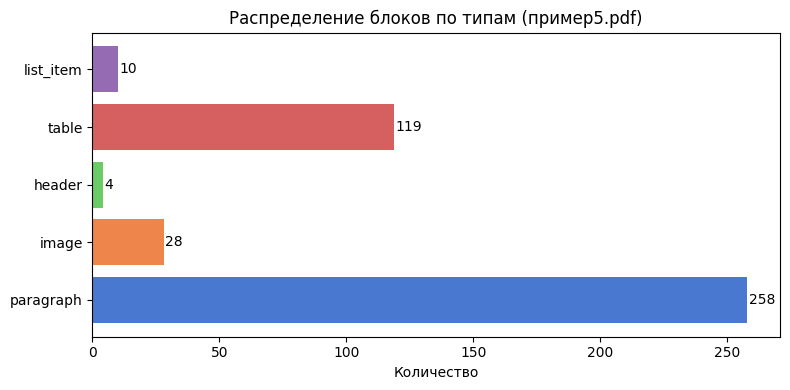

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
types = list(type_counts.keys())
counts = list(type_counts.values())
colors = sns.color_palette('muted', len(types))
bars = ax.barh(types, counts, color=colors)
ax.set_xlabel('Количество')
ax.set_title('Распределение блоков по типам (пример5.pdf)')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(REPORT_IMG, 'primer5_block_types.png'), dpi=150, bbox_inches='tight')
print(f'Сохранено: primer5_block_types.png')
plt.show()

In [4]:
shown_types = set()
print('Примеры блоков каждого типа:')
print('=' * 60)
for block in all_blocks:
    if block.block_type not in shown_types:
        shown_types.add(block.block_type)
        print(f'\nТип: {block.block_type} | Страница: {block.page_num}')
        text_preview = (block.text or '')[:200]
        print(f'Текст: {text_preview}')
        print('-' * 60)
    if len(shown_types) == len(type_counts):
        break

Примеры блоков каждого типа:

Тип: paragraph | Страница: 1
Текст: 1
------------------------------------------------------------

Тип: image | Страница: 1
Текст: 
------------------------------------------------------------

Тип: header | Страница: 7
Текст: КІРІСПЕ
------------------------------------------------------------

Тип: table | Страница: 7
Текст: 09Г2С  пластикалық  болат  кестеде  конструкциялық  болатардың  төмен қоспаланған  жұмыстарын  болат  фосфордың  және  бағыты  негізінен  құрылыста,  жүктеме  магистральдық  метал  мұнай  пайдалануға 
------------------------------------------------------------

Тип: list_item | Страница: 10
Текст: - аққыштық шегі, σ 02 ;  - уақытша қарсыласу, σ в ;   - беріктік қоры, δ;  - микроқаттылық, HV;  - түйірлердің орташа көлемі.    Үлгілерді дайындау.   Бірінші кезеңде қираған жерден фрагменттер кесілі
------------------------------------------------------------


---
## 2. Извлечение и анализ изображений

In [5]:
extractor = ImageExtractor(min_width=50, min_height=50)
extracted_images = extractor.extract_from_pdf(PDF_PATH, output_dir=IMAGES_DIR)

summary = extractor.get_summary(extracted_images)
print(f'Извлечено изображений: {summary["total"]}')
print(f'Страницы с изображениями: {summary.get("pages_list", [])}')
if summary['total'] > 0:
    print(f'Средний размер: {summary["avg_size"]}')

Извлечено изображений: 28
Страницы с изображениями: [1, 2, 3, 4, 5, 6, 11, 12, 13, 14, 18, 19, 27, 28]
Средний размер: (671, 700)


Сохранено: primer5_images_preview.png


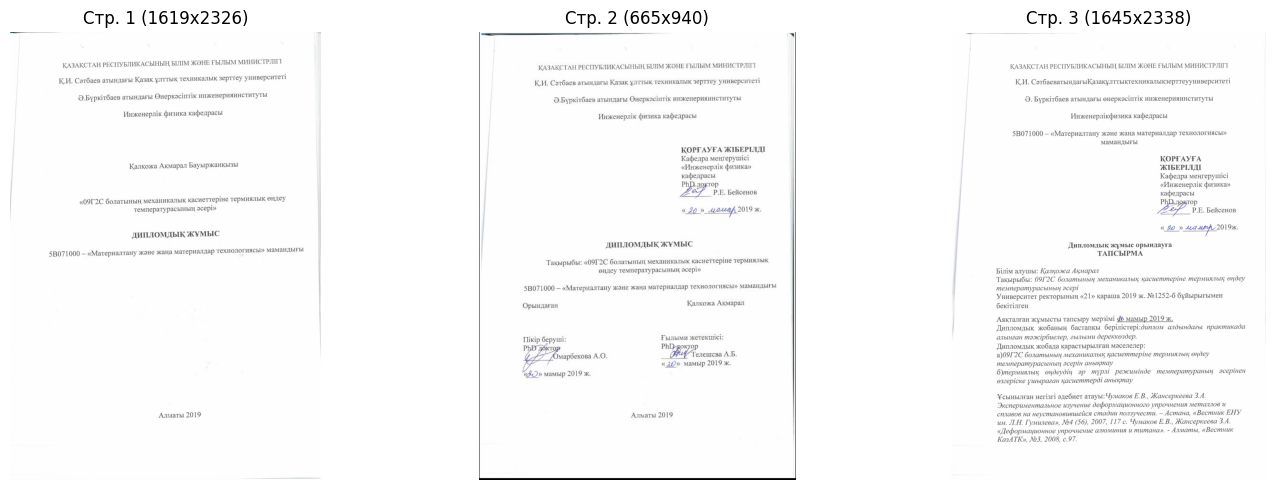

In [6]:
if extracted_images:
    n_show = min(3, len(extracted_images))
    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]
    for i, img_data in enumerate(extracted_images[:n_show]):
        axes[i].imshow(img_data.image)
        axes[i].set_title(f'Стр. {img_data.page_num + 1} ({img_data.width}x{img_data.height})')
        axes[i].axis('off')
    plt.tight_layout()
    fig.savefig(os.path.join(REPORT_IMG, 'primer5_images_preview.png'), dpi=150, bbox_inches='tight')
    print(f'Сохранено: primer5_images_preview.png')
    plt.show()
else:
    print('Изображения не найдены в документе.')

In [7]:
ocr = OCRProcessor()
chart_analyzer = ChartAnalyzer(ocr_processor=ocr, use_clip=True, use_opencv=True, use_blip=True)

analyses = []
if extracted_images:
    analyses = chart_analyzer.analyze_batch(extracted_images)
    print(f'Проанализировано изображений: {len(analyses)}')
    for a in analyses:
        print(f'\n  Стр. {a.page_num}: {a.chart_type_ru} (уверенность: {a.confidence:.0%})')
        if a.blip_caption:
            print(f'  BLIP описание: {a.blip_caption}')
        if a.ocr_text:
            print(f'  OCR текст: {a.ocr_text[:150]}...')
else:
    print('Изображений для анализа нет.')

ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


...

ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


ERROR:src.preprocessing.ocr_processor:OCR failed: tesseract is not installed or it's not in your PATH. See README file for more information.


Проанализировано изображений: 28

  Стр. 1: Блок-схема / диаграмма процесса (уверенность: 24%)
  BLIP описание: this image shows a document with a picture of a man in a suit

  Стр. 2: Математическая формула (уверенность: 31%)
  BLIP описание: this image shows a document with a picture of a man in a suit

  Стр. 3: Таблица с данными (уверенность: 46%)
  BLIP описание: this image shows a document with a picture of a man in a suit

  Стр. 4: Таблица с данными (уверенность: 44%)
  BLIP описание: this image shows a document with a picture of a person in a suit

  Стр. 5: Таблица с данными (уверенность: 60%)
  BLIP описание: this image shows a document with a stamp on it

  Стр. 6: Таблица с данными (уверенность: 35%)
  BLIP описание: this image shows a letter from the president of the russian federation

  Стр. 11: Столбчатая/полосовая диаграмма (уверенность: 31%)
  BLIP описание: this image shows a close up of a wrenet on a table

  Стр. 12: Гистограмма (уверенность: 71%)
  BLIP описание:

---
## 3. Построение Markdown и разбиение на чанки

In [8]:
builder = MarkdownBuilder()
markdown = builder.build(all_blocks, source_name='пример5.pdf')
builder.save(markdown, os.path.join(INDEX_DIR, 'пример5.pdf.md'))

print(f'Markdown: {len(markdown)} символов')
print(f'\nПервые 500 символов Markdown:')
print(markdown[:500])

Markdown: 69856 символов

Первые 500 символов Markdown:
# пример5.pdf


---
*Страница 1*

1

![Изображение со стр. 1](image_p1)


---
*Страница 2*

2

![Изображение со стр. 2](image_p2)


---
*Страница 3*

3

![Изображение со стр. 3](image_p3)


---
*Страница 4*

4

![Изображение со стр. 4](image_p4)


---
*Страница 5*

5

![Изображение со стр. 5](image_p5)


---
*Страница 6*

6

![Изображение со стр. 6](image_p6)


---
*Страница 7*

7

## КІРІСПЕ

Жұмыстың жалпы сипаттамасы .Дипломдық жұмыс 09Г2С болатының  механикалық  қасиеттеріне  ( шегі беріктік


In [9]:
chunker = MarkdownChunker(max_chunk_size=1000, chunk_overlap=100, min_chunk_size=50)
chunks = chunker.chunk_markdown(markdown, source='пример5.pdf')

image_chunks = []
if analyses:
    image_chunks = chunker.create_image_chunks(analyses, source='пример5.pdf')
    chunks.extend(image_chunks)

text_chunks = [c for c in chunks if c.chunk_type == 'text']
table_chunks = [c for c in chunks if c.chunk_type == 'table']
img_chunks = [c for c in chunks if c.chunk_type == 'image_caption']

print(f'Всего чанков: {len(chunks)}')
print(f'  - текстовых: {len(text_chunks)}')
print(f'  - табличных: {len(table_chunks)}')
print(f'  - из изображений: {len(img_chunks)}')

Всего чанков: 107
  - текстовых: 2
  - табличных: 76
  - из изображений: 29


Сохранено: primer5_chunk_sizes.png


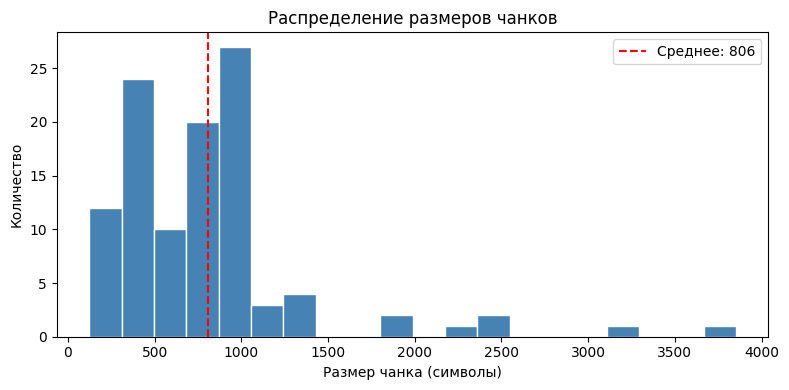

Мин. размер: 123 символов
Макс. размер: 3852 символов
Средний размер: 806 символов


In [10]:
sizes = [len(c.text) for c in chunks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes, bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('Размер чанка (символы)')
ax.set_ylabel('Количество')
ax.set_title('Распределение размеров чанков')
ax.axvline(np.mean(sizes), color='red', linestyle='--', label=f'Среднее: {np.mean(sizes):.0f}')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(REPORT_IMG, 'primer5_chunk_sizes.png'), dpi=150, bbox_inches='tight')
print(f'Сохранено: primer5_chunk_sizes.png')
plt.show()

print(f'Мин. размер: {min(sizes)} символов')
print(f'Макс. размер: {max(sizes)} символов')
print(f'Средний размер: {np.mean(sizes):.0f} символов')

In [11]:
print('Пример текстового чанка:')
print('=' * 60)
if text_chunks:
    c = text_chunks[0]
    print(f'ID: {c.chunk_id}')
    print(f'Тип: {c.chunk_type}')
    print(f'Страница: {c.page}')
    print(f'Раздел: {c.section}')
    print(f'Размер: {len(c.text)} символов')
    print(f'Текст:\n{c.text[:300]}')

if img_chunks:
    print('\n\nПример чанка из изображения:')
    print('=' * 60)
    c = img_chunks[0]
    print(f'ID: {c.chunk_id}')
    print(f'Тип: {c.chunk_type}')
    print(f'Страница: {c.page}')
    print(f'Текст:\n{c.text[:300]}')

Пример текстового чанка:
ID: c137a936
Тип: text
Страница: 35
Раздел: ҚОРЫТЫНДЫ
Размер: 672 символов
Текст:
және  Дипломдық  соғу  жұмыста 09Г2С  жұмсалатын  болатының  динамикалық  термиялық өңдеу  сипатамалары  режимінің  әсерінен механикалық қасиеттерінің өзгерісі көрсетілді. Термиялық өңдеу  режимінің ішінде шынықтыру ,босату, жасыту процестерінің жүруі,болаттың  термиялық өңдеуге дейінгі механикалық 


Пример чанка из изображения:
ID: 54f72c33
Тип: image_caption
Страница: 1
Текст:
---
*Страница 1*

1

![Изображение со стр. 1](image_p1)


---
*Страница 2*

2

![Изображение со стр. 2](image_p2)


---
*Страница 3*

3

![Изображение со стр. 3](image_p3)


---
*Страница 4*

4

![Изображение со стр. 4](image_p4)


---
*Страница 5*

5

![Изображение со стр. 5](image_p5)


---
*Стран


---
## 4. Эмбеддинги и индексация в FAISS

Создаем векторные представления чанков с помощью мультиязычной модели
paraphrase-multilingual-MiniLM-L12-v2 и сохраняем в FAISS-индекс.

In [12]:
embedder = MultimodalEmbedder(use_clip=False)
print(f'Модель: {embedder.text_embedder.model_name}')
print(f'Размерность эмбеддинга: {embedder.dimension}')

embeddings = embedder.embed_chunks(chunks)
print(f'Матрица эмбеддингов: {embeddings.shape}')

vector_store = FAISSVectorStore(dimension=embedder.dimension)
metadata_list = [c.to_dict() for c in chunks]
vector_store.add(embeddings, metadata_list)
vector_store.save(INDEX_DIR)

print(f'Векторов в индексе: {vector_store.size}')
print(f'Индекс сохранен: {INDEX_DIR}')

Модель: paraphrase-multilingual-MiniLM-L12-v2


Размерность эмбеддинга: 384


Матрица эмбеддингов: (107, 384)
Векторов в индексе: 107
Индекс сохранен: ../data/indexes/primer5


Сохранено: primer5_tsne.png


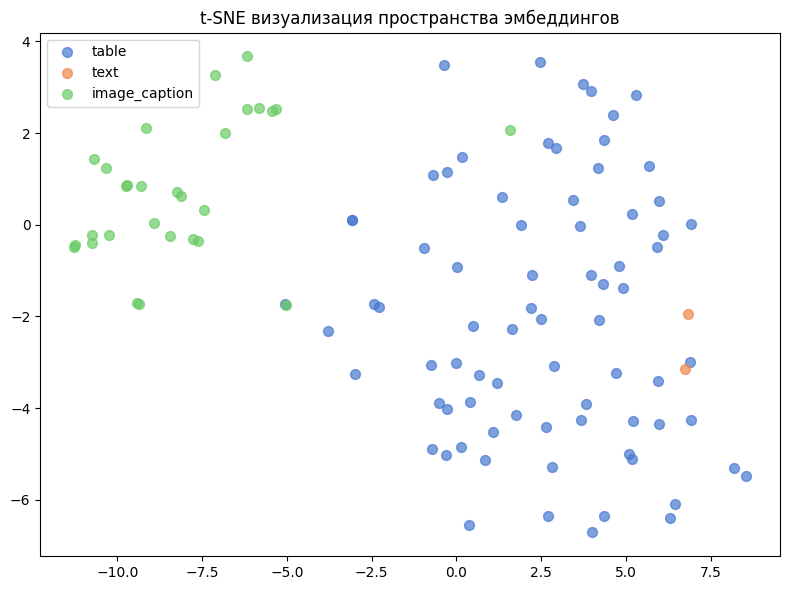

In [13]:
from sklearn.manifold import TSNE

if len(chunks) >= 5:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(chunks)-1))
    coords = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(8, 6))
    chunk_types = [c.chunk_type for c in chunks]
    unique_types = list(set(chunk_types))
    colors_map = {t: sns.color_palette('muted')[i] for i, t in enumerate(unique_types)}

    for ctype in unique_types:
        mask = [i for i, t in enumerate(chunk_types) if t == ctype]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=ctype, alpha=0.7, s=50, color=colors_map[ctype])

    ax.set_title('t-SNE визуализация пространства эмбеддингов')
    ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(REPORT_IMG, 'primer5_tsne.png'), dpi=150, bbox_inches='tight')
    print(f'Сохранено: primer5_tsne.png')
    plt.show()
else:
    print('Недостаточно чанков для t-SNE визуализации.')

---
## 5. Вопрос-ответная система (RAG)

Задаем 4 вопроса к документу: 2 базовых и 2 углубленных.

In [14]:
retriever = MultimodalRetriever(embedder=embedder, vector_store=vector_store, top_k=5)
generator = RAGGenerator(model_name='gpt-oss-20b')

questions = [
    'О чем данная работа? Кратко опишите тему.',
    'Какая структура у данной работы?',
    'Какие методы и подходы использовались в исследовании?',
    'Какие основные выводы и рекомендации сделаны в работе?',
]

qa_results = []

for i, question in enumerate(questions, 1):
    print(f'\n{"="*70}')
    print(f'Вопрос {i}: {question}')
    print('=' * 70)

    results = retriever.retrieve(question, top_k=5)

    context_parts = []
    for j, r in enumerate(results, 1):
        source_info = ''
        if r.get('page'):
            source_info = f' (стр. {r["page"]}'
            if r.get('section'):
                source_info += f', раздел: {r["section"]}'
            source_info += ')'
        context_parts.append(f'[Фрагмент {j}]{source_info}:\n{r["text"]}')
    context = '\n\n---\n\n'.join(context_parts)

    response = generator.generate(question, context)
    answer = response['answer']

    print(f'\nОтвет ({response["model"]}):')
    print(answer)

    print(f'\nИсточники:')
    for j, r in enumerate(results[:3], 1):
        score = r['score']
        page = r.get('page', '?')
        text_preview = r['text'][:80]
        print(f'  {j}. score={score:.4f} | стр. {page} | {text_preview}...')

    qa_results.append({
        'question': question,
        'answer': answer,
        'context': context,
        'sources': results,
    })


Вопрос 1: О чем данная работа? Кратко опишите тему.



Ответ (gpt-oss-20b):
Данная работа посвящена исследованию краткосрочных механических свойств и микроструктурного состояния стали 09Г2С. В ней рассматриваются такие параметры, как предел прочности, сопротивление, прочность к разрыву, микро‑прочность (HV) и средний размер зерен. Описывается подготовка образцов из разломанных участков, схема изготовления проб и проведение механических испытаний.

Источники:
  1. score=0.5318 | стр. 8 | лген кешенді | зерттеулердің объектісі болып табылады. |
| --- | --- | --- | ---...
  2. score=0.5064 | стр. 8 | болаттың көмегімен дайындайды. |
| --- | --- | --- | --- | --- | --- | --- |

--...
  3. score=0.5036 | стр. 15 | -- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---...

Вопрос 2: Какая структура у данной работы?



Ответ (gpt-oss-20b):
**Структура работы, как видно из представленного контекста:**

1. **Кіріспе (Введение)** – в начале документа содержится раздел «КІРІСПЕ», где перечислены цели исследования (пункты 1‑3).  
2. **Три основные раздела** – далее в тексте встречаются подпункты «I II III», что указывает на наличие трёх главных разделов, каждый из которых посвящён отдельному аспекту исследования (например, термическая обработка, механические свойства, микроструктура).  
3. **Графические и табличные материалы** – в фрагментах упоминаются рисунки (с подпунктами (a), (b)) и таблицы, что свидетельствует о наличии иллюстраций и таблиц в соответствующих разделах.  

Таким образом, работа структурирована следующим образом: **Введение → раздел I → раздел II → раздел III** (с графиками, таблицами и описаниями). Дополнительные разделы (выводы, список литературы и т.п.) в предоставленном контексте не упоминаются.

Источники:
  1. score=0.6409 | стр. 15 | -- | --- | --- | --- | --- | --- | --- | ---


Ответ (gpt-oss-20b):
В исследовании использовались следующие методы и подходы:

1. **Подготовка образцов** – разрезание фрагментов от кристаллического кристалла, формирование проб согласно схеме, показанной на рисунке 1.  
2. **Краткосрочные механические испытания** – измерение предела текучести (σ₀₂), предела прочности (σᵥ), сопротивления к разрыву (δ), микротрёпкости (HV) и среднего размера зерен.  
3. **Микроскопический анализ** – изучение микроструктуры с помощью микроскопа, показанного на рисунке 8.  
4. **Термическая обработка** – нагрев образцов при 600 °C, 650 °C, 700 °C и 750 °C по 30 минут, после чего проводилось измерение микротрёпкости.  
5. **Экспериментальный подход** – проведение серии испытаний и наблюдений, позволяющих оценить влияние термической обработки и условий доставки на свойства стали 09Г2С.  

Таким образом, исследование сочетало подготовку проб, механические испытания, микроскопический анализ и термическую обработку как основные методы и подходы.

Источники:


Ответ (gpt-oss-20b):
В предоставленном контексте нет информации, позволяющей сформулировать основные выводы и рекомендации, сделанные в работе.

Источники:
  1. score=0.4993 | стр. 8 | болаттың көмегімен дайындайды. |
| --- | --- | --- | --- | --- | --- | --- |

--...
  2. score=0.4884 | стр. 8 | лген кешенді | зерттеулердің объектісі болып табылады. |
| --- | --- | --- | ---...
  3. score=0.4473 | стр. 15 | -- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---...


---
## 6. Оценка качества ответов

Вычисляем метрики BLEU, ROUGE-L и Faithfulness.

In [15]:
references = [
    'Работа посвящена исследованию определенной научной темы.',
    'Работа состоит из введения, теоретической части, практической части и заключения.',
    'В работе применялись различные методы и подходы к исследованию.',
    'В работе сделаны выводы и даны рекомендации по результатам исследования.',
]

metrics_list = []
for i, (qa, ref) in enumerate(zip(qa_results, references)):
    metrics = evaluate_response(
        question=qa['question'],
        reference=ref,
        hypothesis=qa['answer'],
        context=qa['context'],
    )
    metrics_list.append(metrics)
    bleu = metrics['bleu']
    rouge = metrics['rouge_l']
    faith = metrics['faithfulness']
    print(f'Вопрос {i+1}: BLEU={bleu:.4f}  ROUGE-L={rouge:.4f}  Faithfulness={faith:.4f}')

avg_bleu = np.mean([m['bleu'] for m in metrics_list])
avg_rouge = np.mean([m['rouge_l'] for m in metrics_list])
avg_faith = np.mean([m['faithfulness'] for m in metrics_list])
print(f'\nСредние значения:')
print(f'  BLEU:         {avg_bleu:.4f}')
print(f'  ROUGE-L:      {avg_rouge:.4f}')
print(f'  Faithfulness: {avg_faith:.4f}')

Вопрос 1: BLEU=0.0539  ROUGE-L=0.0000  Faithfulness=0.0833
Вопрос 2: BLEU=0.0044  ROUGE-L=0.0000  Faithfulness=0.1013
Вопрос 3: BLEU=0.0199  ROUGE-L=0.0000  Faithfulness=0.1744
Вопрос 4: BLEU=0.2100  ROUGE-L=0.0000  Faithfulness=0.0000

Средние значения:
  BLEU:         0.0721
  ROUGE-L:      0.0000
  Faithfulness: 0.0897


Сохранено: primer5_metrics.png


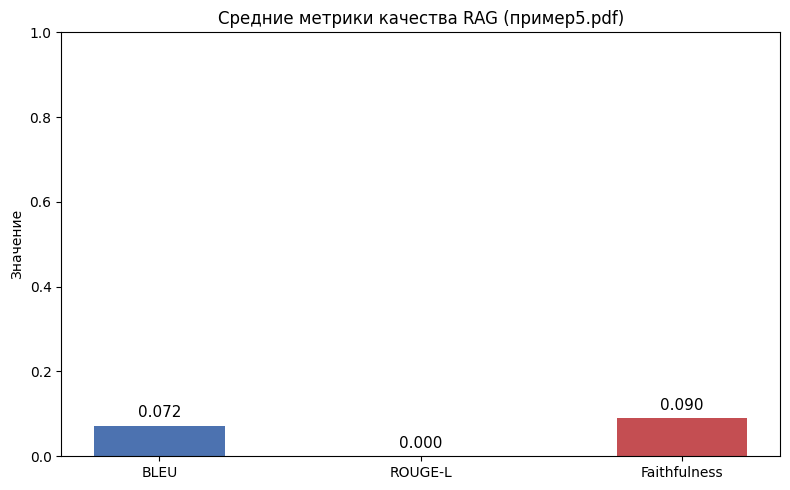

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
metric_names = ['BLEU', 'ROUGE-L', 'Faithfulness']
avg_values = [avg_bleu, avg_rouge, avg_faith]
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.bar(metric_names, avg_values, color=colors, width=0.5)
ax.set_ylabel('Значение')
ax.set_title('Средние метрики качества RAG (пример5.pdf)')
ax.set_ylim(0, 1.0)

for bar, val in zip(bars, avg_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
fig.savefig(os.path.join(REPORT_IMG, 'primer5_metrics.png'), dpi=150, bbox_inches='tight')
print(f'Сохранено: primer5_metrics.png')
plt.show()

---
## Итоги

В данном ноутбуке был продемонстрирован полный цикл работы мультимодальной RAG-системы на файле **пример5.pdf**:

- Извлечение и классификация структурных блоков
- Анализ изображений с помощью CLIP, BLIP, OCR и OpenCV
- Семантическое разбиение на чанки с перекрытием
- Создание мультиязычных эмбеддингов (paraphrase-multilingual-MiniLM-L12-v2)
- Индексация в FAISS и поиск релевантных фрагментов
- Генерация ответов через GPT API с оценкой качества